In [1]:
!pip install wordcloud

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import string
import nltk

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from wordcloud import WordCloud

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [3]:
data = {
    'Review_ID': ['R1','R2','R3','R4','R5'],
    'Customer_Review': [
        "Great food and fast service!",
        "Cold food. Terribly slow experience.",
        "Average taste but friendly staff.",
        "Bad management, food was late.",
        "Loved the desserts and quick serving!"
    ],
    'Service_Rating':[5,1,3,2,5]
}

df = pd.DataFrame(data)

df

,Review_ID,Customer_Review,Service_Rating
0,R1,Great food and fast service!,5
1,R2,Cold food. Terribly slow experience.,1
2,R3,Average taste but friendly staff.,3
3,R4,"Bad management, food was late.",2
4,R5,Loved the desserts and quick serving!,5


In [4]:
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df['Clean_Review'] = df['Customer_Review'].apply(preprocess)

df[['Customer_Review','Clean_Review']]

,Customer_Review,Clean_Review
0,Great food and fast service!,great food fast service
1,Cold food. Terribly slow experience.,cold food terribly slow experience
2,Average taste but friendly staff.,average taste friendly staff
3,"Bad management, food was late.",bad management food late
4,Loved the desserts and quick serving!,loved desserts quick serving


In [5]:
vectorizer = CountVectorizer()

X = vectorizer.fit_transform(df['Clean_Review'])

print(X.toarray())

print(vectorizer.get_feature_names_out())

[[0 0 0 0 0 1 1 0 1 0 0 0 0 1 0 0 0 0 0]
 [0 0 1 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0 1]
 [1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 1 0]
 [0 1 0 0 0 0 1 0 0 1 0 1 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 1 0 1 0 1 0 0 0 0]]
['average' 'bad' 'cold' 'desserts' 'experience' 'fast' 'food' 'friendly'
 'great' 'late' 'loved' 'management' 'quick' 'service' 'serving' 'slow'
 'staff' 'taste' 'terribly']


In [6]:
y = df['Service_Rating']

model = MultinomialNB()

model.fit(X,y)

prediction = model.predict(X)

print("Predicted Ratings")

print(prediction)

Predicted Ratings
[5 1 3 2 5]


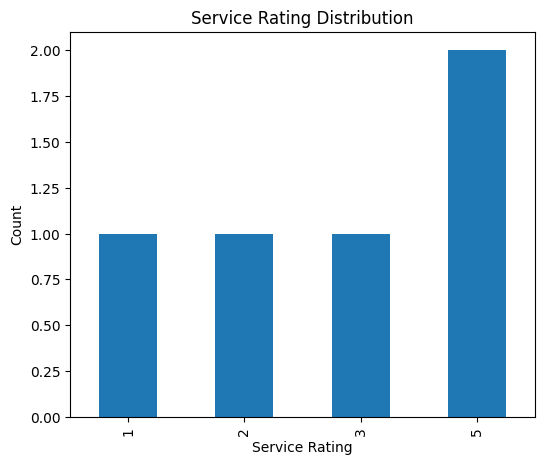

In [7]:
plt.figure(figsize=(6,5))

df['Service_Rating'].value_counts().sort_index().plot(kind='bar')

plt.title("Service Rating Distribution")
plt.xlabel("Service Rating")
plt.ylabel("Count")

plt.show()

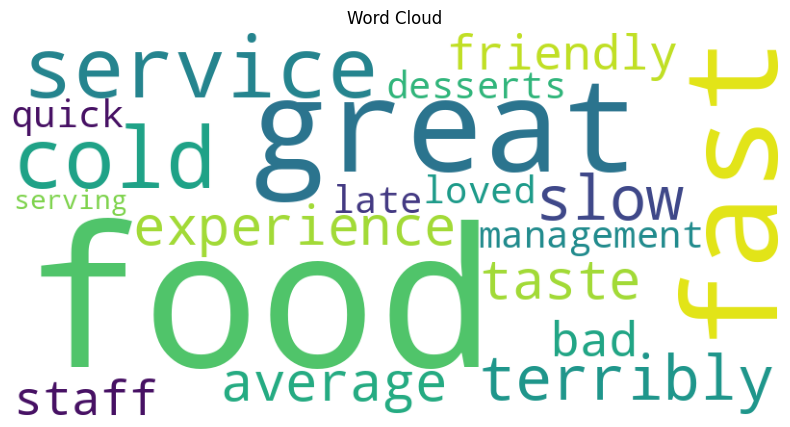

In [8]:
text = " ".join(df['Clean_Review'])

wordcloud = WordCloud(
    background_color='white',
    width=800,
    height=400
).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud")
plt.show()

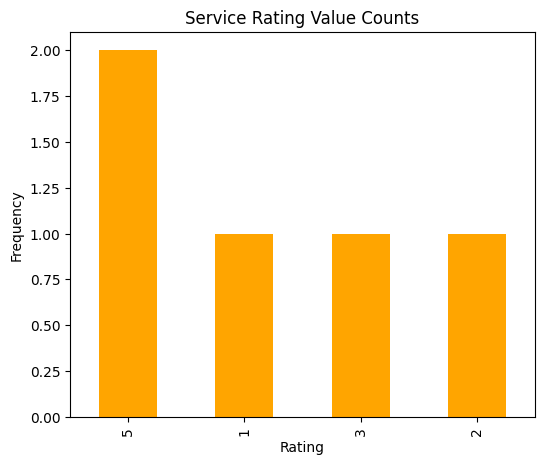

In [9]:
plt.figure(figsize=(6,5))

df['Service_Rating'].value_counts().plot(kind='bar', color='orange')

plt.title("Service Rating Value Counts")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.show()